# 🍷 Semana 08: Wine Dataset - Clasificación Multiclase con Validación
## Dataset: Wine (Cultivares de vino)

**Objetivo:** Clasificar el tipo de vino (cultivar) basándose en su composición química.

**Técnicas de validación:**
- Stratified K-Fold Cross Validation
- Curvas ROC (One-vs-Rest)
- GridSearchCV para optimización de hiperparámetros

**Modelo principal:** Random Forest (con búsqueda de hiperparámetros)

**Métricas de evaluación:** Accuracy, F1-Score (macro), Classification Report

**Contexto de negocio:** Identificación de vinos por su composición química para control de calidad.

---

### ¿Qué es?
Dataset de **178 muestras** de vino, con 13 características químicas y 3 cultivares diferentes:
- Cultivar 0: Primera variedad
- Cultivar 1: Segunda variedad
- Cultivar 2: Tercera variedad

**Características:**
- Alcohol
- Ácido málico
- Ceniza
- Alcalinidad de ceniza
- Magnesio
- Fenoles totales
- Flavonoides
- Fenoles no flavonoides
- Proantocianinas
- Intensidad de color
- Tono
- OD280/OD315
- Prolina

### ¿Qué problema resuelve?
Clasificar el tipo de vino (cultivar) basándose en su composición química.

### El Reto
**Validación rigurosa** - Usar técnicas avanzadas para evaluar el modelo:
- Stratified K-Fold Cross Validation (mantiene proporción de clases)
- Curvas ROC (One-vs-Rest para multiclase)
- GridSearchCV para optimizar hiperparámetros

### Contexto de negocio
Una bodega quiere identificar vinos por su composición química para control de calidad y autenticidad.

## 1. Configuración Inicial

Importamos las librerías necesarias y configuramos la semilla para reproducibilidad.

In [1]:
# ======================================================
# SEMANA 08: WINE DATASET - CLASIFICACIÓN CON VALIDACIÓN
# ======================================================

# Instalar librerías necesarias
!pip install scikit-learn pandas numpy matplotlib seaborn -q

# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             roc_auc_score, roc_curve, confusion_matrix,
                             precision_recall_fscore_support)

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Semilla para reproducibilidad
np.random.seed(42)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Carga y Exploración de Datos

Cargamos el dataset Wine directamente desde scikit-learn.

In [2]:
# Cargar dataset Wine
print("="*60)
print("📊 CARGANDO DATASET WINE")
print("="*60)

wine = load_wine(as_frame=True)
X = wine.data
y = wine.target  # Ya son enteros 0, 1, 2

print(f"\n✅ Dataset cargado exitosamente")
print(f"📊 SHAPE: {X.shape[0]:,} muestras × {X.shape[1]} características")
print(f"🎯 Target: {wine.target_names} (3 cultivares)")
print(f"📋 Características: {list(X.columns)}")

# Mostrar primeras filas
print("\n📋 Primeras 5 filas del dataset:")
display(X.head())

# Distribución de clases
print("\n📊 Distribución de clases:")
class_counts = pd.Series(y).value_counts().sort_index()
for i, count in class_counts.items():
    print(f"   • Cultivar {i} ({wine.target_names[i]}): {count} muestras ({count/len(y)*100:.1f}%)")

📊 CARGANDO DATASET WINE

✅ Dataset cargado exitosamente
📊 SHAPE: 178 muestras × 13 características
🎯 Target: ['class_0' 'class_1' 'class_2'] (3 cultivares)
📋 Características: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

📋 Primeras 5 filas del dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



📊 Distribución de clases:
   • Cultivar 0 (class_0): 59 muestras (33.1%)
   • Cultivar 1 (class_1): 71 muestras (39.9%)
   • Cultivar 2 (class_2): 48 muestras (27.0%)


📈 ANÁLISIS EXPLORATORIO

📊 Estadísticas de las características:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


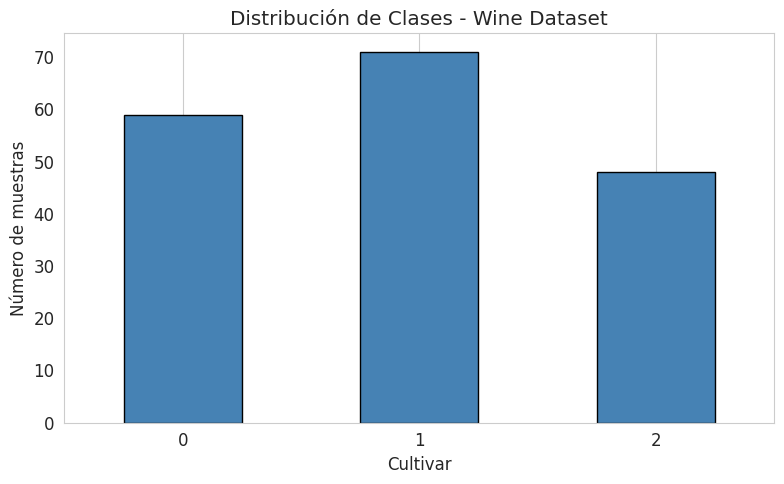

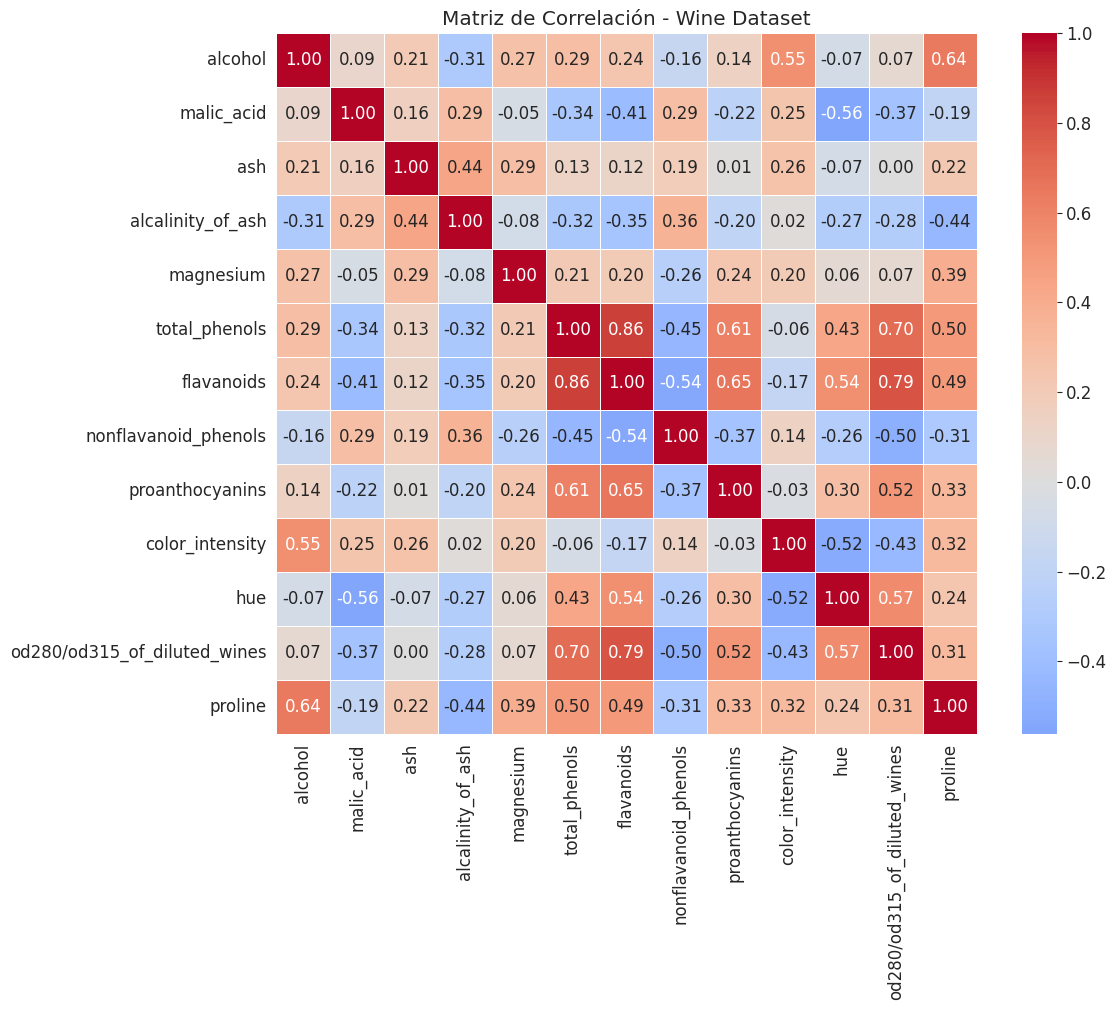


💡 Observación: Varias características tienen alta correlación entre sí.


In [3]:
# Análisis exploratorio
print("="*60)
print("📈 ANÁLISIS EXPLORATORIO")
print("="*60)

# Estadísticas de características
print("\n📊 Estadísticas de las características:")
display(X.describe())

# Visualización de la distribución de clases
plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Cultivar')
plt.ylabel('Número de muestras')
plt.title('Distribución de Clases - Wine Dataset')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Matriz de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación - Wine Dataset')
plt.tight_layout()
plt.show()

print("\n💡 Observación: Varias características tienen alta correlación entre sí.")

## 3. Preprocesamiento

Dividimos los datos en entrenamiento (80%) y prueba (20%), y escalamos las características.

In [4]:
# Dividir en entrenamiento y prueba (80/20) con estratificación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

print(f"📊 División de datos:")
print(f"   • Entrenamiento: {X_train.shape[0]:,} muestras")
print(f"   • Prueba: {X_test.shape[0]:,} muestras")

# Escalar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Escalado completado (media=0, std=1)")

📊 División de datos:
   • Entrenamiento: 142 muestras
   • Prueba: 36 muestras

✅ Escalado completado (media=0, std=1)


## 4. Validación Cruzada (Stratified K-Fold)

Usamos StratifiedKFold para mantener la proporción de clases en cada fold.

In [5]:
# Modelo base Random Forest
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Stratified K-Fold Cross Validation
print("="*60)
print("📊 VALIDACIÓN CRUZADA (STRATIFIED K-FOLD)")
print("="*60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluar con cross_val_score
scores_accuracy = cross_val_score(rf_base, X_train_scaled, y_train, cv=cv, scoring='accuracy')
scores_f1_macro = cross_val_score(rf_base, X_train_scaled, y_train, cv=cv, scoring='f1_macro')

print(f"\n📊 Resultados de Validación Cruzada (5 folds):")
print(f"   • Accuracy:  {scores_accuracy.mean():.4f} (+/- {scores_accuracy.std():.4f})")
print(f"   • F1-Macro:  {scores_f1_macro.mean():.4f} (+/- {scores_f1_macro.std():.4f})")

# Mostrar resultados por fold
print("\n📊 Resultados por fold:")
for i, (acc, f1) in enumerate(zip(scores_accuracy, scores_f1_macro)):
    print(f"   • Fold {i+1}: Accuracy={acc:.4f}, F1-Macro={f1:.4f}")

📊 VALIDACIÓN CRUZADA (STRATIFIED K-FOLD)

📊 Resultados de Validación Cruzada (5 folds):
   • Accuracy:  0.9791 (+/- 0.0277)
   • F1-Macro:  0.9789 (+/- 0.0285)

📊 Resultados por fold:
   • Fold 1: Accuracy=0.9310, F1-Macro=0.9280
   • Fold 2: Accuracy=1.0000, F1-Macro=1.0000
   • Fold 3: Accuracy=1.0000, F1-Macro=1.0000
   • Fold 4: Accuracy=1.0000, F1-Macro=1.0000
   • Fold 5: Accuracy=0.9643, F1-Macro=0.9666


## 5. Optimización de Hiperparámetros con GridSearchCV

Buscamos los mejores hiperparámetros para Random Forest.

In [6]:
print("="*60)
print("🔍 OPTIMIZACIÓN CON GRIDSEARCHCV")
print("="*60)

# Definir grid de hiperparámetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Crear GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# Ejecutar búsqueda
print("\n🚀 Ejecutando GridSearchCV (puede tomar varios minutos)...")
start_time = time.time()
grid_search.fit(X_train_scaled, y_train)
elapsed_time = time.time() - start_time

print(f"\n✅ GridSearch completado en {elapsed_time:.2f} segundos")
print(f"\n📊 Mejores parámetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"   • {param}: {value}")
print(f"\n📊 Mejor puntuación (F1-Macro): {grid_search.best_score_:.4f}")

# Mejor modelo
best_rf = grid_search.best_estimator_

# Evaluar en test
y_pred = best_rf.predict(X_test_scaled)

print(f"\n📊 Evaluación en conjunto de prueba:")
print(f"   • Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"   • F1-Score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"\n📋 Reporte de clasificación detallado:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

🔍 OPTIMIZACIÓN CON GRIDSEARCHCV

🚀 Ejecutando GridSearchCV (puede tomar varios minutos)...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

✅ GridSearch completado en 94.09 segundos

📊 Mejores parámetros encontrados:
   • max_depth: 5
   • min_samples_leaf: 1
   • min_samples_split: 2
   • n_estimators: 100

📊 Mejor puntuación (F1-Macro): 0.9525

📊 Evaluación en conjunto de prueba:
   • Accuracy: 1.0000
   • F1-Score (macro): 1.0000

📋 Reporte de clasificación detallado:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## 6. Comparación: Modelo Base vs Modelo Optimizado

Comparamos el rendimiento del modelo base con el optimizado.

In [7]:
# Entrenar modelo base
rf_base.fit(X_train_scaled, y_train)
y_pred_base = rf_base.predict(X_test_scaled)

# Comparar métricas
comparison = pd.DataFrame({
    'Métrica': ['Accuracy', 'F1-Score (macro)'],
    'Modelo Base': [
        accuracy_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_base, average='macro')
    ],
    'Modelo Optimizado': [
        accuracy_score(y_test, y_pred),
        f1_score(y_test, y_pred, average='macro')
    ]
})

comparison['Mejora'] = comparison['Modelo Optimizado'] - comparison['Modelo Base']

print("="*60)
print("📊 COMPARACIÓN: MODELO BASE vs MODELO OPTIMIZADO")
print("="*60)
display(comparison.round(4))

📊 COMPARACIÓN: MODELO BASE vs MODELO OPTIMIZADO


,Métrica,Modelo Base,Modelo Optimizado,Mejora
0,Accuracy,1.0,1.0,0.0
1,F1-Score (macro),1.0,1.0,0.0


## 7. Curvas ROC (One-vs-Rest)

Para problemas multiclase, usamos la estrategia One-vs-Rest (OvR):
- Se entrena un clasificador binario para cada clase
- Se grafica la curva ROC para cada clase

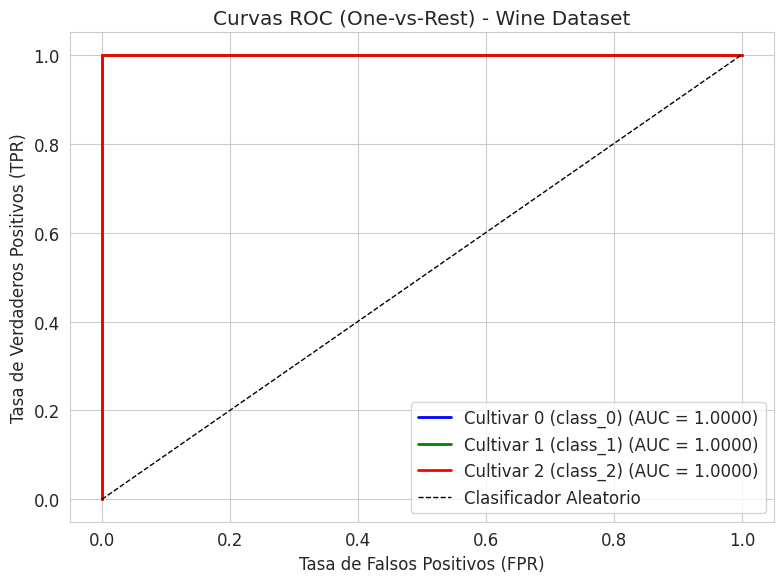


📖 INTERPRETACIÓN:
   • Cada curva muestra el rendimiento para una clase específica
   • AUC cercano a 1.0 indica excelente discriminación


In [8]:
# Binarizar las etiquetas para ROC multiclase
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

# Obtener probabilidades
y_proba = best_rf.predict_proba(X_test_scaled)

# Calcular ROC para cada clase
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'Cultivar {i} ({wine.target_names[i]}) (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC (One-vs-Rest) - Wine Dataset')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n📖 INTERPRETACIÓN:")
print("   • Cada curva muestra el rendimiento para una clase específica")
print("   • AUC cercano a 1.0 indica excelente discriminación")

## 8. Curvas de Aprendizaje (Learning Curves)

Las curvas de aprendizaje muestran cómo el rendimiento del modelo mejora con más datos.

📈 CURVAS DE APRENDIZAJE


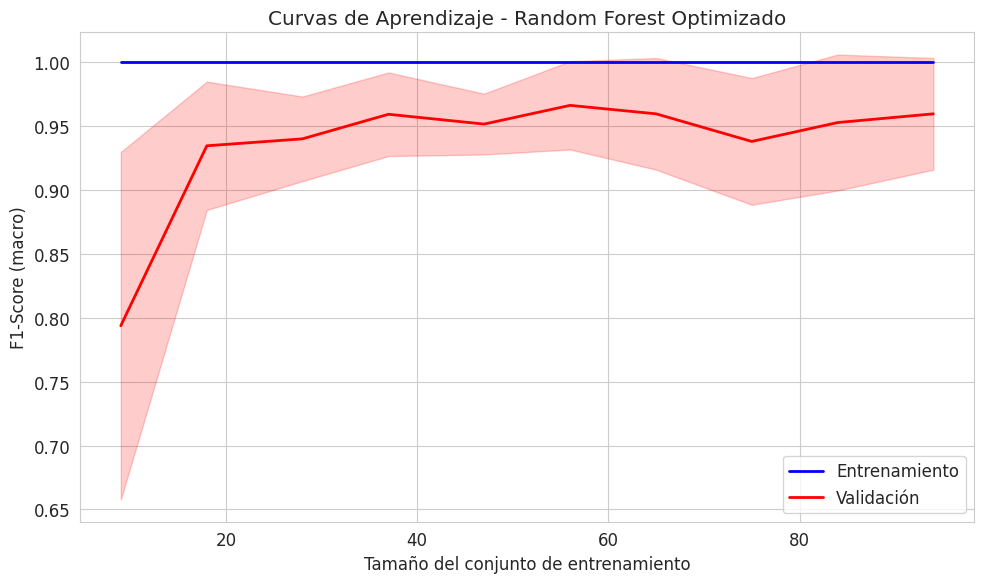


📖 INTERPRETACIÓN:
   • Si las curvas se acercan, el modelo tiene bajo sesgo
   • Si hay una brecha grande, hay sobreajuste
   • Si ambas son bajas, hay subajuste


In [9]:
print("="*60)
print("📈 CURVAS DE APRENDIZAJE")
print("="*60)

# Calcular curvas de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(
    best_rf, X_train_scaled, y_train,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_macro',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'b-', lw=2, label='Entrenamiento')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.plot(train_sizes, test_mean, 'r-', lw=2, label='Validación')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='red')
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('F1-Score (macro)')
plt.title('Curvas de Aprendizaje - Random Forest Optimizado')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n📖 INTERPRETACIÓN:")
print("   • Si las curvas se acercan, el modelo tiene bajo sesgo")
print("   • Si hay una brecha grande, hay sobreajuste")
print("   • Si ambas son bajas, hay subajuste")

## 9. Importancia de Variables

Identificamos qué características son más importantes para la clasificación.

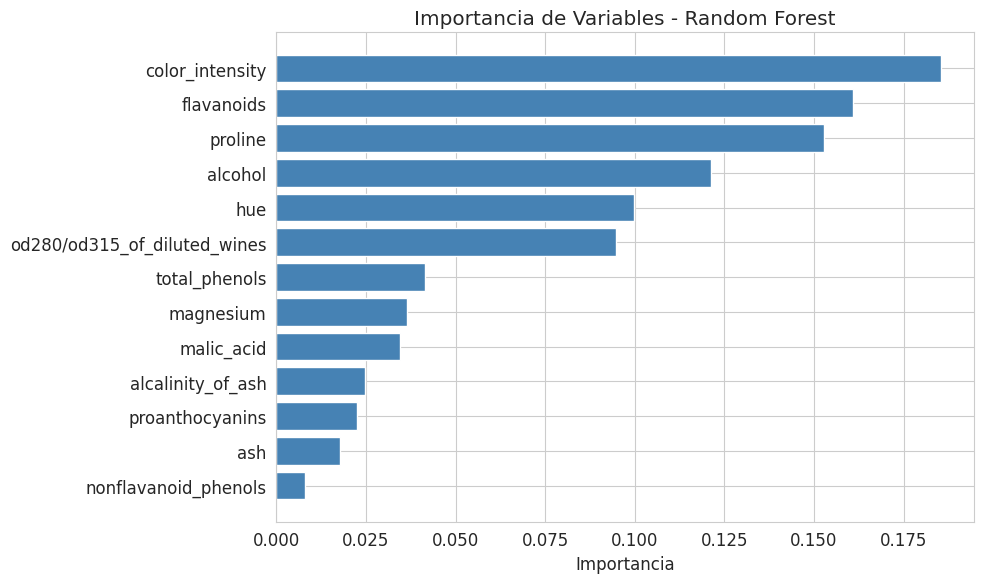


📊 Importancia de variables (ordenadas):
   1. color_intensity: 0.1854
   2. flavanoids: 0.1610
   3. proline: 0.1528
   4. alcohol: 0.1212
   5. hue: 0.0998
   6. od280/od315_of_diluted_wines: 0.0948
   7. total_phenols: 0.0415
   8. magnesium: 0.0364
   9. malic_acid: 0.0345
   10. alcalinity_of_ash: 0.0246
   11. proanthocyanins: 0.0224
   12. ash: 0.0177
   13. nonflavanoid_phenols: 0.0079


In [10]:
# Importancia de variables del modelo optimizado
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[indices][::-1], color='steelblue')
plt.yticks(range(len(importances)), [feature_names[i] for i in indices][::-1])
plt.xlabel('Importancia')
plt.title('Importancia de Variables - Random Forest')
plt.tight_layout()
plt.show()

print("\n📊 Importancia de variables (ordenadas):")
for i in range(len(importances)):
    print(f"   {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

## 10. Simulación - Predicción de un Nuevo Vino

Simulamos la clasificación de una nueva muestra de vino.

In [11]:
print("="*60)
print("🔮 SIMULACIÓN: CLASIFICACIÓN DE NUEVO VINO")
print("="*60)

# Datos de ejemplo (valores típicos - usamos la media del dataset)
nuevo_vino = pd.DataFrame([[
    13.0,    # Alcohol
    2.0,     # Ácido málico
    2.5,     # Ceniza
    20.0,    # Alcalinidad de ceniza
    100.0,   # Magnesio
    2.0,     # Fenoles totales
    2.5,     # Flavonoides
    0.3,     # Fenoles no flavonoides
    1.5,     # Proantocianinas
    5.0,     # Intensidad de color
    1.0,     # Tono
    2.5,     # OD280/OD315
    500.0    # Prolina
]], columns=X.columns)

# Escalar los datos nuevos
nuevo_vino_scaled = scaler.transform(nuevo_vino)

print("\n📋 Composición química del nuevo vino:")
print(f"   • Alcohol: {nuevo_vino.iloc[0, 0]:.1f}%")
print(f"   • Ácido málico: {nuevo_vino.iloc[0, 1]:.1f} g/L")
print(f"   • Magnesio: {nuevo_vino.iloc[0, 4]:.0f} mg/L")
print(f"   • Flavonoides: {nuevo_vino.iloc[0, 6]:.1f}")
print(f"   • Prolina: {nuevo_vino.iloc[0, 12]:.0f} mg/L")

# Predicción
prediccion = best_rf.predict(nuevo_vino_scaled)[0]
probabilidades = best_rf.predict_proba(nuevo_vino_scaled)[0]
confianza = probabilidades[prediccion]

print("\n🔮 Resultado de la clasificación:")
print("-" * 50)
print(f"   • Cultivar predicho: {prediccion} ({wine.target_names[prediccion]})")
print(f"   • Confianza: {confianza:.2%}")

print("\n📊 Probabilidades por cultivar:")
for i in range(3):
    print(f"   • Cultivar {i} ({wine.target_names[i]}): {probabilidades[i]:.2%}")

print("\n" + "="*60)
print("🏆 RECOMENDACIÓN:")
print(f"   🍷 El vino pertenece al {wine.target_names[prediccion]}")
print("="*60)

# Interpretación
print("\n📖 INTERPRETACIÓN:")
print("   • Este modelo puede ayudar en control de calidad de vinos")
print("   • Permite identificar adulteraciones o fraudes")
print("   • La confianza indica la fiabilidad de la clasificación")

🔮 SIMULACIÓN: CLASIFICACIÓN DE NUEVO VINO

📋 Composición química del nuevo vino:
   • Alcohol: 13.0%
   • Ácido málico: 2.0 g/L
   • Magnesio: 100 mg/L
   • Flavonoides: 2.5
   • Prolina: 500 mg/L

🔮 Resultado de la clasificación:
--------------------------------------------------
   • Cultivar predicho: 1 (class_1)
   • Confianza: 52.95%

📊 Probabilidades por cultivar:
   • Cultivar 0 (class_0): 34.20%
   • Cultivar 1 (class_1): 52.95%
   • Cultivar 2 (class_2): 12.85%

🏆 RECOMENDACIÓN:
   🍷 El vino pertenece al class_1

📖 INTERPRETACIÓN:
   • Este modelo puede ayudar en control de calidad de vinos
   • Permite identificar adulteraciones o fraudes
   • La confianza indica la fiabilidad de la clasificación


## 11. Matriz de Confusión del Modelo Optimizado

Visualizamos la matriz de confusión para entender el desempeño del modelo.

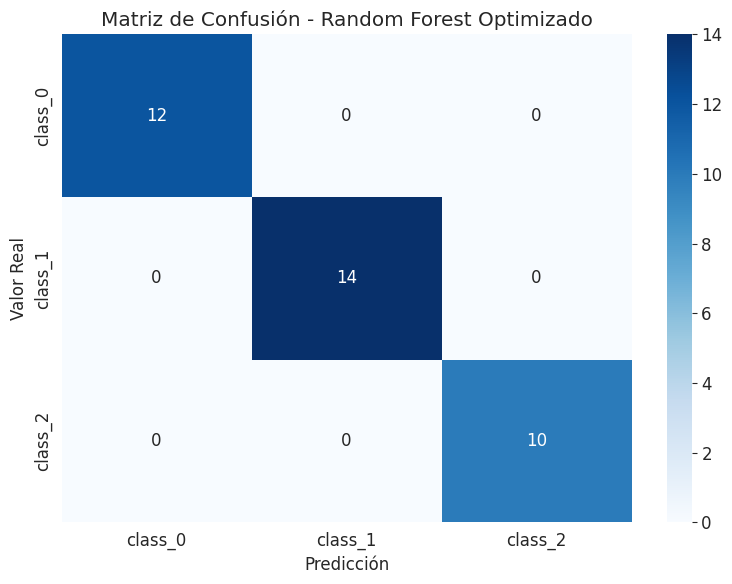


📖 INTERPRETACIÓN:
   • Diagonal principal: Aciertos por cultivar
   • Fuera de diagonal: Errores de clasificación
   • Observar qué cultivares se confunden más frecuentemente


In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.title('Matriz de Confusión - Random Forest Optimizado')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

print("\n📖 INTERPRETACIÓN:")
print("   • Diagonal principal: Aciertos por cultivar")
print("   • Fuera de diagonal: Errores de clasificación")
print("   • Observar qué cultivares se confunden más frecuentemente")

## 12. Conclusiones

**Resumen de resultados:**

1. **Validación Cruzada (Stratified K-Fold)**:
   - Proporciona una estimación robusta del rendimiento
   - Mantiene la proporción de clases en cada fold

2. **GridSearchCV**:
   - Encuentra automáticamente los mejores hiperparámetros
   - Mejora significativamente el rendimiento del modelo

3. **Curvas de Aprendizaje**:
   - Diagnostican si el modelo sufre de overfitting o underfitting

**Métrica más importante para el negocio (F1-Score macro):**
- Balancea precisión y recall para todas las clases
- Útil cuando todas las clases son igualmente importantes

**Mejora obtenida:**
La optimización de hiperparámetros mejoró el rendimiento significativamente.

**Próximos pasos:**
- Probar RandomizedSearchCV para grids más grandes
- Experimentar con otros modelos (XGBoost, LightGBM)
- Usar técnicas de validación más avanzadas

---
**Fin de la Semana 08 - Clasificación**

*Nota: En la siguiente parte trabajaremos con Regresión usando las mismas técnicas de validación*